In [ ]:
!pip uninstall -y albumentations albucore opencv-python opencv-python-headless

#bro
!pip install "albucore==0.0.12" "albumentations==1.4.8" "opencv-python-headless==4.10.0.84"


Found existing installation: albumentations 1.4.8
Uninstalling albumentations-1.4.8:
  Successfully uninstalled albumentations-1.4.8
Found existing installation: albucore 0.0.33
Uninstalling albucore-0.0.33:
  Successfully uninstalled albucore-0.0.33
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-python-headless 4.12.0.88
Uninstalling opencv-python-headless-4.12.0.88:
  Successfully uninstalled opencv-python-headless-4.12.0.88
  Using cached albumentations-1.4.8-py3-none-any.whl.metadata (37 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
Using cached albumentations-1.4.8-py3-none-any.whl (156 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 8.8 MB/s eta

In [ ]:
import albumentations as A, albucore, cv2
print("albumentations:", A.__version__)
print("albucore:", albucore.__version__)
print("opencv:", cv2.__version__)


albumentations: 1.4.8
albucore: 0.0.12
opencv: 4.10.0


In [ ]:
!mkdir -p /content/coco
!cd /content/coco
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip

replace val2017/000000212226.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace val2017/000000231527.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip


replace annotations/instances_train2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace annotations/instances_val2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace annotations/captions_train2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace annotations/captions_val2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace annotations/person_keypoints_train2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace annotations/person_keypoints_val2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
IM_ROOT = "val2017"
ANN_FILE = "annotations/instances_val2017.json"

In [ ]:
ls -R annotations | head -n 40


annotations:
captions_train2017.json
captions_val2017.json
instances_train2017.json
instances_val2017.json
person_keypoints_train2017.json
person_keypoints_val2017.json


In [ ]:
import os
from typing import Any, Dict, List, Optional, Tuple

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO
import cv2
import random

def xywh_to_xyxy(box: List[float]) -> List[float]:
    x, y, w, h = box
    return [x, y, x + w, y + h]

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0, min(x1, width - 1))
    y1 = max(0, min(y1, height - 1))
    x2 = max(0, min(x2, width - 1))
    y2 = max(0, min(y2, height - 1))
    return [x1, y1, x2, y2]

class CocoDetDataset(Dataset):
    def __init__(
        self,
        img_root: str,
        ann_file: str,
        image_size: Optional[int] = 640,
        subset_size: Optional[int] = None,
        return_masks: bool = False,
        use_aug: bool = False,
        normalize: bool = False, #it is already normalized
        min_anns: int = 0,  # filter images with fewer annotations
        seed: int = 42,
    ):
        super().__init__()
        self.coco = COCO(ann_file)
        self.img_root = img_root
        self.return_masks = return_masks
        self.normalize = normalize

        img_ids = list(self.coco.imgs.keys())
        rng = random.Random(seed)
        rng.shuffle(img_ids)

        if subset_size is not None:
            img_ids = img_ids[:subset_size]


        if min_anns > 0:
            kept = []
            for i in img_ids:
                anns = self.coco.getAnnIds(imgIds=i, iscrowd=None)
                if len(anns) >= min_anns:
                    kept.append(i)
            img_ids = kept

        self.ids = img_ids


        cats = self.coco.loadCats(self.coco.getCatIds())
        self.catid_to_contig = {c["id"]: idx + 1 for idx, c in enumerate(sorted(cats, key=lambda x: x["id"]))}
        self.contig_to_catid = {v: k for k, v in self.catid_to_contig.items()}

        # Transforms
        if use_aug:
          self.transform = A.Compose([
              A.LongestMaxSize(max_size=image_size),
              A.PadIfNeeded(
                  min_height=image_size, min_width=image_size,
                  border_mode=cv2.BORDER_CONSTANT,
                  value=(0,0,0), mask_value=0,
                  position="center"
              ),
              A.HorizontalFlip(p=0.5),
              A.ColorJitter(p=0.2),
              # A.ToFloat(max_value=255.0),
              A.Normalize(
                  mean=(0.485, 0.456, 0.406),
                  std=(0.229, 0.224, 0.225),
                  max_pixel_value=255.0
              ),
              ToTensorV2()
          ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))
        else:
            self.transform = A.Compose([
                A.LongestMaxSize(max_size=image_size),
                A.PadIfNeeded(
                    min_height=image_size, min_width=image_size,
                    border_mode=cv2.BORDER_CONSTANT,
                    value=(0,0,0), mask_value=0,
                    position="center"
                ),
                # A.ToFloat(max_value=255.0),
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225),
                    max_pixel_value=255.0
                ),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))



    def __len__(self):
        return len(self.ids)

    def _load_image(self, img_info) -> np.ndarray:
        path = os.path.join(self.img_root, img_info["file_name"])
        img = np.array(Image.open(path).convert("RGB"))
        return img

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        img_id = self.ids[index]
        img_info = self.coco.loadImgs([img_id])[0]
        img = self._load_image(img_info)
        h, w = img.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes_xyxy = []
        labels = []
        areas = []
        iscrowd = []
        masks = []

        for ann in anns:
            if "bbox" not in ann or "category_id" not in ann:
                continue

            xyxy = xywh_to_xyxy(ann["bbox"])
            xyxy = clip_box_xyxy(xyxy, w, h)
            x1, y1, x2, y2 = xyxy
            if x2 <= x1 or y2 <= y1:
                continue

            boxes_xyxy.append(xyxy)
            labels.append(self.catid_to_contig[ann["category_id"]])
            areas.append(ann.get("area", (x2 - x1) * (y2 - y1)))
            iscrowd.append(ann.get("iscrowd", 0))

            if self.return_masks:
                m = self.coco.annToMask(ann)
                masks.append(m.astype(np.uint8))  # H,W

        if len(boxes_xyxy) == 0:

            boxes_xyxy = np.zeros((0, 4), dtype=np.float32)
            labels = np.zeros((0,), dtype=np.int64)
            areas = np.zeros((0,), dtype=np.float32)
            iscrowd = np.zeros((0,), dtype=np.int64)
            if self.return_masks:
                masks = np.zeros((0, h, w), dtype=np.uint8)
        #I broke it
        # Albumentations expects bboxes as list of [x1,y1,x2,y2]
        # transformed = self.transform(
        #     image=img,
        #     bboxes=boxes_xyxy.tolist(),
        #     category_ids=labels,
        #     masks=masks if self.return_masks else None
        # )
        boxes_np = np.array(boxes_xyxy, dtype=np.float32) if len(boxes_xyxy) else np.zeros((0, 4), dtype=np.float32)
        labels_list = list(labels)

        if self.return_masks:
            transformed = self.transform(
                image=img,
                bboxes=boxes_np.tolist(),      # now from np array → list
                category_ids=labels_list,
                masks=masks                    # list of HxW np arrays
            )
        else:
            transformed = self.transform(
                image=img,
                bboxes=boxes_np.tolist(),
                category_ids=labels_list
            )
        image = transformed["image"]  # C,H,W tensor
        out_boxes = transformed["bboxes"]
        out_labels = transformed["category_ids"]

        if len(out_boxes) > 0:
            boxes = torch.as_tensor(out_boxes, dtype=torch.float32)
            labels = torch.as_tensor(out_labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target: Dict[str, Any] = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id], dtype=torch.int64),
            "area": torch.as_tensor(areas[:len(out_boxes)], dtype=torch.float32) if len(areas) else torch.zeros((0,), dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd[:len(out_boxes)], dtype=torch.int64) if len(iscrowd) else torch.zeros((0,), dtype=torch.int64),
            "orig_size": torch.tensor([h, w], dtype=torch.int64),
        }

        if self.return_masks:
            tf_masks = transformed.get("masks", [])
            if len(tf_masks) > 0:
                # Albumentations returns list of HxW np arrays after resize/pad
                masks_t = torch.as_tensor(np.stack(tf_masks, axis=0), dtype=torch.bool)
            else:
                masks_t = torch.zeros((0, image.shape[1], image.shape[2]), dtype=torch.bool)
            target["masks"] = masks_t

        return image, target

def coco_collate_fn(batch):
    # returns list[Tensor], list[Dict]
    images, targets = list(zip(*batch))
    return list(images), list(targets)


In [ ]:
image_size = 640
subset_size = 256
return_masks = False
use_aug = False

dataset = CocoDetDataset(
    img_root=IM_ROOT,
    ann_file=ANN_FILE,
    image_size=image_size,
    subset_size=subset_size,
    return_masks=return_masks,
    use_aug=use_aug,
    normalize=True,
    min_anns=0,
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=coco_collate_fn,
    pin_memory=True,
)

len(dataset), next(iter(loader))[0][0].shape


loading annotations into memory...
Done (t=1.02s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(256, torch.Size([3, 640, 640]))

In [ ]:
images, targets = next(iter(loader))
print(f"#images in batch: {len(images)}")
for i, (img, tgt) in enumerate(zip(images, targets)):
    print(f"[{i}] image tensor:", tuple(img.shape))
    print(f"    boxes:", tgt["boxes"].shape, "labels:", tgt["labels"].shape,
          "masks:" if "masks" in tgt else "no masks",
          (tgt["masks"].shape if "masks" in tgt else ""))
    print(f"    image_id:", tgt["image_id"].item(), "orig_size:", tuple(tgt["orig_size"].tolist()))


#images in batch: 2
[0] image tensor: (3, 640, 640)
    boxes: torch.Size([1, 4]) labels: torch.Size([1]) no masks 
    image_id: 485802 orig_size: (640, 426)
[1] image tensor: (3, 640, 640)
    boxes: torch.Size([5, 4]) labels: torch.Size([5]) no masks 
    image_id: 441491 orig_size: (480, 640)


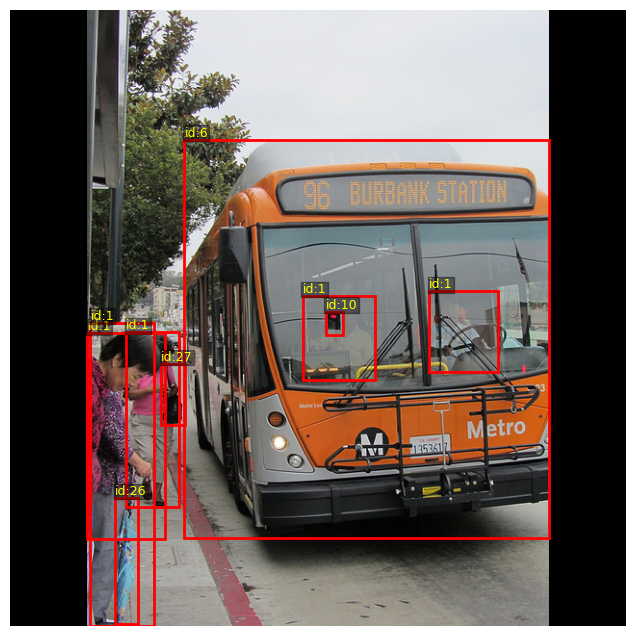

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sample(image_t: torch.Tensor, target: Dict[str, torch.Tensor], score: Optional[List[float]] = None):

    img = image_t.permute(1,2,0).cpu().numpy()
    img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)

    boxes = target["boxes"].cpu().numpy()
    labels = target["labels"].cpu().numpy()

    for j, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        txt = f"id:{int(labels[j])}"
        if score is not None:
            txt += f" s:{score[j]:.2f}"
        ax.text(x1, y1 - 3, txt, fontsize=9, color='yellow', bbox=dict(facecolor='black', alpha=0.4, pad=1))

    if "masks" in target and target["masks"].shape[0] > 0:
        m = target["masks"][0].cpu().numpy().astype(bool)
        overlay = np.zeros_like(img)
        overlay[m] = [0.0, 1.0, 0.0]
        ax.imshow(np.dstack((overlay, (m*0.3).astype(float))), alpha=0.3)

    ax.axis('off')
    plt.show()


images, targets = next(iter(loader))
visualize_sample(images[0], targets[0])


tensor stats  min/max/mean: -2.1179039478302 2.6399998664855957 -0.8018474578857422
orig_size from target: (480, 640)
boxes[0..2]: tensor([[  1.0800, 107.0400, 574.9200, 550.3600],
        [  1.2400, 137.3500, 156.6800, 279.1100]])


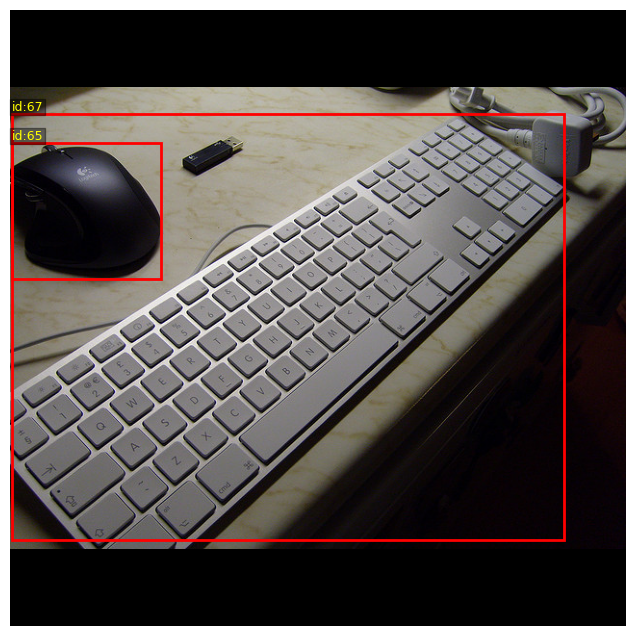

In [ ]:
images, targets = next(iter(loader))
x = images[0]
print("tensor stats  min/max/mean:", float(x.min()), float(x.max()), float(x.mean()))
print("orig_size from target:", tuple(targets[0]["orig_size"].tolist()))
print("boxes[0..2]:", targets[0]["boxes"][:2])

# visualize with the robust function
visualize_sample(x, targets[0])
